# Sprint 3 — Baseline ML (Classifieurs classiques)

**AquaSense AI · EHTP MIG S4 · Contexte Maroc**

**Runtime : CPU** (local ou Jupyter — pas besoin de Colab ni de GPU).

Objectifs :
- Split stratifié 80/20
- Entraîner LR, KNN, Random Forest, XGBoost
- GridSearchCV sur RF et XGBoost (5-fold)
- Métriques : F1-Macro, recall `needs repair`, matrices de confusion
- Sauvegarder les modèles dans `models/`

> Colab + GPU → uniquement à partir du **Sprint 4** (Deep Learning).

## Prérequis (local)

```bash
pip install -r requirements.txt
python src/preprocessing.py   # si data/cleaned/ absent
```

In [14]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import PumpPreprocessor
from src.train import (
    NEEDS_REPAIR,
    get_encoded_feature_names,
    get_pipeline_prep_clf,
    load_training_data,
    train_baselines,
)

sns.set_theme(style="whitegrid")
REPORTS = PROJECT_ROOT / "reports"

## 1. Chargement des données nettoyées

In [ ]:
df = load_training_data()
feature_cols = PumpPreprocessor().get_feature_columns()
print("Shape :", df.shape)
print("Features :", len(feature_cols))
df["status_group"].value_counts(normalize=True).mul(100).round(1)

Shape : (59400, 37)
Features : 26


status_group
functional                 54.3
non functional             38.4
functional needs repair     7.3
Name: proportion, dtype: float64

## 2. Entraînement des 4 baselines + GridSearch RF/XGB

Stratégie imbalance : `class_weight='balanced'` (LR, RF), `sample_weight` balanced (XGB).

In [ ]:
results = train_baselines(tune=True, save=True)


=== Entraînement logistic_regression ===
  F1-Macro=0.4773 | Recall needs repair=0.5550 | CV=0.4833376382804251

=== Entraînement knn ===
  F1-Macro=0.6232 | Recall needs repair=0.2839 | CV=0.6156180791800332

=== Entraînement random_forest ===
  F1-Macro=0.6658 | Recall needs repair=0.4844 | CV=0.6576079204223938

=== Entraînement xgboost ===
  F1-Macro=0.6554 | Recall needs repair=0.6385 | CV=0.6516671873051725

=== GridSearch Random Forest ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1}
  F1-Macro=0.6658

=== GridSearch XGBoost ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__subsample': 0.8}
  F1-Macro=0.6570

=== Champion : random_forest_tuned (F1-Macro=0.6658) ===
Métriques → C:\Users\MOH\Documents\AquaSense_AI\reports\sprint_03_metrics.json
Modèles → 

## 3. Tableau comparatif

In [ ]:
comparison = pd.DataFrame(results["comparison"])
comparison = comparison.sort_values("f1_macro", ascending=False)
display(comparison)
print(f"\nChampion : {results['champion']}")

,model,f1_macro,f1_needs_repair,recall_needs_repair,accuracy,roc_auc,latency_ms
0,random_forest_tuned,0.665796,0.425013,0.484357,0.758586,0.872354,0.027358
1,random_forest,0.665796,0.425013,0.484357,0.758586,0.872354,0.022396
2,xgboost_tuned,0.657027,0.433659,0.641947,0.734259,0.877377,0.023792
3,xgboost,0.655363,0.434886,0.638470,0.731902,0.873131,0.016235
4,knn,0.623151,0.348259,0.283893,0.743603,0.823760,0.301491
5,logistic_regression,0.477290,0.247417,0.555041,0.536700,0.724278,0.002830



Champion : random_forest_tuned


## 4. Matrices de confusion (heatmaps normalisées)

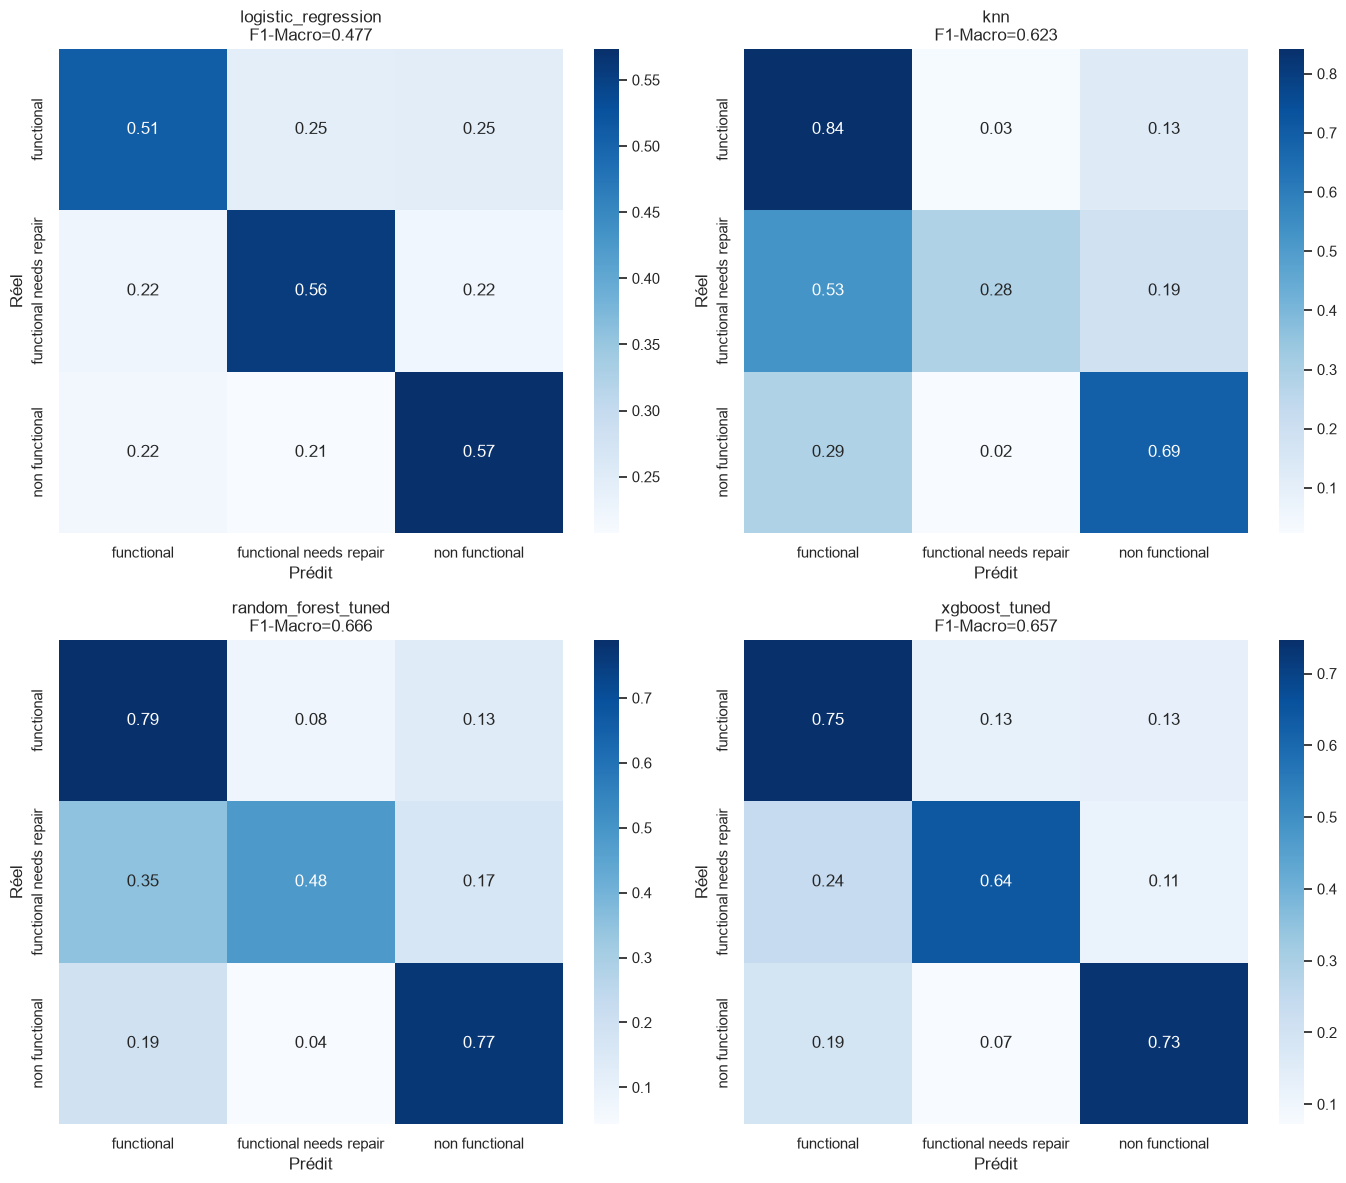

In [ ]:
X_test = results["X_test"]
y_test = results["y_test"]
models_to_plot = ["logistic_regression", "knn", "random_forest_tuned", "xgboost_tuned"]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, name in zip(axes, models_to_plot):
    pipe = results["trained_models"][name]
    y_pred = pipe.predict(X_test)
    cm = pd.crosstab(y_test, y_pred, normalize="index")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax)
    f1 = results["models"][name]["metrics"]["f1_macro"]
    ax.set_title(f"{name}\nF1-Macro={f1:.3f}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.savefig(REPORTS / "sprint_03_confusion_matrices.png", dpi=120)
plt.show()

## 5. Feature importance — Random Forest & XGBoost (top 20)

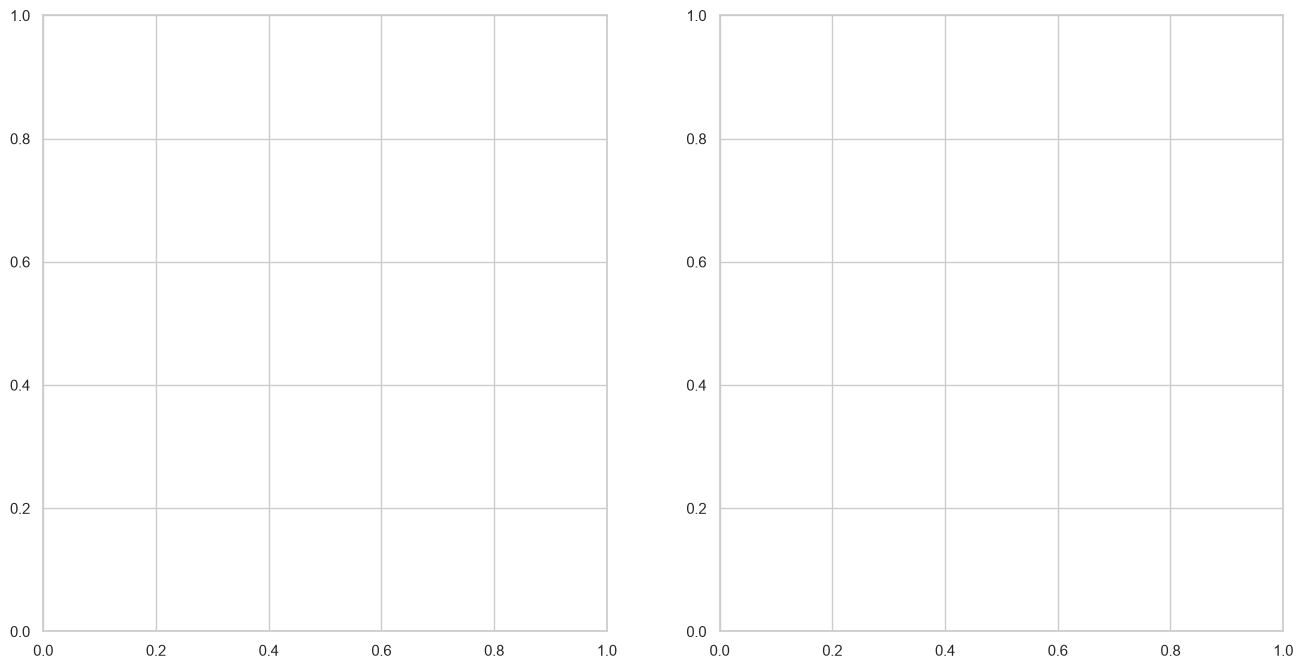

In [ ]:
def plot_importance(pipe, title, ax):
    prep, clf = get_pipeline_prep_clf(pipe)
    names = get_encoded_feature_names(prep)
    imp = clf.feature_importances_
    idx = np.argsort(imp)[-20:]
    top_names = [names[i] for i in idx]
    top_imp = imp[idx]
    ax.barh(top_names, top_imp, color="#2ecc71")
    ax.set_title(title)
    ax.invert_yaxis()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_importance(results["trained_models"]["random_forest_tuned"], "RF (tuned)", axes[0])
plot_importance(results["trained_models"]["xgboost_tuned"], "XGBoost (tuned)", axes[1])
plt.tight_layout()
plt.savefig(REPORTS / "sprint_03_feature_importance.png", dpi=120)
plt.show()

## 6. Critères d'acceptation Sprint 3

In [ ]:
import json

champ = results["champion"]
m = results["models"][champ]["metrics"]
best_recall = max(
    info["metrics"]["recall_per_class"].get(NEEDS_REPAIR, 0)
    for info in results["models"].values()
)

# Inclure la passe recall boost si disponible
recall_boost_path = REPORTS / "sprint_03_recall_boost.json"
recall_boost_champion = None
if recall_boost_path.exists():
    with open(recall_boost_path, encoding="utf-8") as f:
        rb = json.load(f)
    recall_boost_champion = rb.get("champion")
    best_recall = max(
        best_recall,
        max(
            info["metrics"]["recall_per_class"].get(NEEDS_REPAIR, 0)
            for info in rb.get("models", {}).values()
        ),
    )

checks = pd.DataFrame(
    [
        ["4+ modèles entraînés", len(results["models"]) >= 4, len(results["models"])],
        ["F1-Macro champion ≥ 0.72", m["f1_macro"] >= 0.72, round(m["f1_macro"], 4)],
        ["Recall needs repair ≥ 0.65 (ML + recall boost)", best_recall >= 0.65, round(best_recall, 4)],
        ["Modèles sauvegardés", (PROJECT_ROOT / "models/rf_best_v1.joblib").exists(), "models/"],
        ["Recall boost exécuté", recall_boost_path.exists(), recall_boost_champion or "non"],
    ],
    columns=["Critère", "OK", "Valeur"],
)
display(checks)

## 7. Prochaine étape

**Sprint 4 — Deep Learning** : MLP, ResidualMLP ou 1D-CNN sur les mêmes features (MinMaxScaler).